# MLP Character-Level Language Model

Implementation of a character-level name generator based on
[Bengio et al. (2003)](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)
*"A Neural Probabilistic Language Model"*.

**Architecture:**
```
Input (character indices)
  → Embedding table C      : (vocab_size, EMBED_DIM)
  → Flatten context window : (BLOCK_SIZE * EMBED_DIM,)
  → Linear + Tanh          : (HIDDEN_DIM,)
  → Linear                 : (vocab_size,)   ← logits
  → Softmax / Cross-Entropy
```

| Symbol | Meaning |
|--------|---------|
| `BLOCK_SIZE` | Number of prior characters used as context |
| `EMBED_DIM` | Dimensionality of each character embedding |
| `HIDDEN_DIM` | Width of the hidden (tanh) layer |
| `'.'` (index 0) | Special boundary token (start padding + end-of-word) |

## 1. Imports

- `torch` / `torch.nn.functional` — tensor operations and loss functions
- `matplotlib` — plotting the training loss curve and embedding space
- `random` — shuffling the dataset before splitting

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

%matplotlib inline

In [2]:
import mlflow, os

# Ensure cwd is project root (names.txt lives there)
if not os.path.exists('names.txt') and os.path.exists('../names.txt'):
    os.chdir('..')

os.makedirs('checkpoints', exist_ok=True)
mlflow.set_experiment('makemore')
_mlflow_run = mlflow.start_run(run_name='part2-mlp')
print(f'MLflow run started  id={_mlflow_run.info.run_id}')

MLflow run started  id=3b941b5517d7493fb55d2633486d558f


## 2. Data Loading & Vocabulary Building

Each line in `names.txt` is one name (e.g. `"emma"`).

We build two lookup tables:
- `stoi` (string → int): maps each character to a unique integer index
- `itos` (int → string): reverse mapping used when decoding predictions

The special token `'.'` is assigned index **0** and serves as both the left-padding
character (filling the context before the first real character) and the end-of-word
target (the model learns to emit it to terminate generation).

In [3]:
# Load the raw word list
words = open('names.txt', 'r').read().splitlines()
print(f"Dataset : {len(words):,} words")
print(f"Examples: {words[:8]}")

# Build character vocabulary
chars = sorted(list(set(''.join(words))))   # all unique characters, sorted
stoi  = {s: i + 1 for i, s in enumerate(chars)}  # 'a'→1, 'b'→2, …
stoi['.'] = 0                                      # boundary token → 0
itos  = {i: s for s, i in stoi.items()}            # reverse mapping

vocab_size = len(itos)                             # 27  (26 letters + '.')
print(f"Vocab   : {vocab_size} tokens  {itos}")

Dataset : 32,033 words
Examples: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
Vocab   : 27 tokens  {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


## 3. Dataset Construction

We convert each word into a sequence of `(context, target)` integer pairs using
a **sliding window** of width `BLOCK_SIZE`.

Example with `BLOCK_SIZE = 3` and the word `"emma"`:

```
context        → target
['.','.','.' ] → 'e'
['.','.',e'  ] → 'm'
['.',e','m'  ] → 'm'
['e','m','m' ] → 'a'
['m','m','a' ] → '.'
```

The dataset is shuffled once and split **80 / 10 / 10** into train, dev (validation),
and test sets.  
We never touch the test set during development — it gives a final unbiased evaluation.

In [4]:
BLOCK_SIZE = 3  # context length: number of prior characters used to predict the next one

def build_dataset(words):
    """
    Given a list of words, produce (X, Y) tensors:
      X  shape (N, BLOCK_SIZE) — integer context windows
      Y  shape (N,)            — integer target characters

    Each word is padded on the left with BLOCK_SIZE boundary tokens
    and terminated on the right with a single boundary token.
    The window slides one position to the right after each character.
    """
    X, Y = [], []
    for w in words:
        context = [0] * BLOCK_SIZE        # left-pad with boundary token index 0
        for ch in w + '.':               # iterate through word + end token
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # slide window right by 1
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

# Shuffle once so splits are random but reproducible
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1])    # 80 %  training
Xdev, Ydev = build_dataset(words[n1:n2])  # 10 %  validation
Xte,  Yte  = build_dataset(words[n2:])    # 10 %  test

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## 4. MLP Architecture — Forward Pass Walkthrough

Before we train, this cell traces **one forward pass** step-by-step with toy weights
to make the shapes and math explicit.

| Step | Operation | Output shape |
|------|-----------|-------------|
| 1 | Embedding lookup `C[context]` | `(N, BLOCK_SIZE, EMBED_DIM)` |
| 2 | Flatten context embeddings | `(N, BLOCK_SIZE × EMBED_DIM)` |
| 3 | Hidden layer: `tanh(x @ W1 + b1)` | `(N, HIDDEN_DIM)` |
| 4 | Output layer: `h @ W2 + b2` | `(N, vocab_size)` |
| 5 | Cross-entropy loss | scalar |

> **Baseline loss**: a random model assigns equal probability `1/vocab_size` to every
> character, giving an expected loss of `log(vocab_size) ≈ 3.30`. Any trained model
> should fall well below this.

In [5]:
import math
torch.manual_seed(42)

_EMBED, _HID = 2, 100   # tiny dimensions just for demonstration

# Step 1 — Embedding lookup
_C   = torch.randn((vocab_size, _EMBED))
_emb = _C[Xtr[:5]]                                  # (5, BLOCK_SIZE, _EMBED)
print(f"1. Embedding lookup : {tuple(_emb.shape)}")

# Step 2 — Flatten context window into one vector per sample
_flat = _emb.view(-1, BLOCK_SIZE * _EMBED)           # (5, BLOCK_SIZE*_EMBED)
print(f"2. Flattened        : {tuple(_flat.shape)}")

# Step 3 — Hidden layer with tanh non-linearity
_W1  = torch.randn((BLOCK_SIZE * _EMBED, _HID))
_b1  = torch.randn(_HID)
_h   = torch.tanh(_flat @ _W1 + _b1)                # (5, _HID)
print(f"3. Hidden (tanh)    : {tuple(_h.shape)}")

# Step 4 — Output layer → logits (unnormalized log-probabilities)
_W2     = torch.randn((_HID, vocab_size))
_b2     = torch.randn(vocab_size)
_logits = _h @ _W2 + _b2                            # (5, vocab_size)
print(f"4. Logits           : {tuple(_logits.shape)}")

# Step 5 — Cross-entropy loss
#   Internally: softmax(_logits) → negative log-likelihood of correct class
_loss = F.cross_entropy(_logits, Ytr[:5])
print(f"\n5. Loss (random init): {_loss.item():.4f}")
print(f"   Uniform baseline : {math.log(vocab_size):.4f}  (= log({vocab_size}))")

1. Embedding lookup : (5, 3, 2)
2. Flattened        : (5, 6)
3. Hidden (tanh)    : (5, 100)
4. Logits           : (5, 27)

5. Loss (random init): 9.2754
   Uniform baseline : 3.2958  (= log(27))


## 5. Model Initialization

We now initialize the **real** model parameters with a fixed random seed so
results are reproducible.

| Parameter | Shape | Role |
|-----------|-------|------|
| `C` | `(27, 10)` | Embedding table — one 10-D vector per character |
| `W1`, `b1` | `(30, 200)`, `(200,)` | Hidden layer weights and biases |
| `W2`, `b2` | `(200, 27)`, `(27,)` | Output layer weights and biases |

Total parameters ≈ **11 k** — small enough to train in seconds on CPU.

In [6]:
EMBED_DIM  = 10   # each character → 10-dimensional dense vector
HIDDEN_DIM = 200  # neurons in the hidden layer

g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((vocab_size, EMBED_DIM),              generator=g)  # embedding table
W1 = torch.randn((BLOCK_SIZE * EMBED_DIM, HIDDEN_DIM), generator=g)  # hidden weights
b1 = torch.randn(HIDDEN_DIM,                           generator=g)  # hidden biases
W2 = torch.randn((HIDDEN_DIM, vocab_size),             generator=g)  # output weights
b2 = torch.randn(vocab_size,                           generator=g)  # output biases

parameters = [C, W1, b1, W2, b2]

# Enable PyTorch autograd so .backward() fills in .grad for each parameter
for p in parameters:
    p.requires_grad = True

print(f"Total trainable parameters: {sum(p.nelement() for p in parameters):,}")

Total trainable parameters: 11,897


## 6. Training Loop

We use **mini-batch SGD** (stochastic gradient descent):

1. **Sample** a random batch of 32 examples from the training set
2. **Forward pass** — compute logits and cross-entropy loss
3. **Backward pass** — call `loss.backward()` to populate `.grad` on every parameter
4. **Update** — nudge each parameter in the negative gradient direction

**Learning rate schedule** (step decay):
- `lr = 0.1` for the first 100 k steps (fast initial descent)
- `lr = 0.01` for the last 100 k steps (fine-tuning near the minimum)

We track `log10(loss)` rather than raw loss because it compresses the early
large-loss region and makes the curve easier to read.

In [7]:
MAX_STEPS  = 200_000
BATCH_SIZE = 32

stepi, lossi = [], []

for i in range(MAX_STEPS):

    # 1. Random mini-batch indices
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,))

    # 2. Forward pass
    emb    = C[Xtr[ix]]                                                   # (B, BLOCK_SIZE, EMBED_DIM)
    h      = torch.tanh(emb.view(-1, BLOCK_SIZE * EMBED_DIM) @ W1 + b1)  # (B, HIDDEN_DIM)
    logits = h @ W2 + b2                                                  # (B, vocab_size)
    loss   = F.cross_entropy(logits, Ytr[ix])

    # 3. Backward pass — zero gradients first to prevent accumulation across steps
    for p in parameters:
        p.grad = None
    loss.backward()

    # 4. SGD parameter update with step-decay learning rate
    lr = 0.1 if i < MAX_STEPS // 2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # Track step and log10(loss) for plotting
    stepi.append(i)
    lossi.append(loss.log10().item())

print(f"Final mini-batch loss: {loss.item():.4f}")

Final mini-batch loss: 1.5249


### Loss Curve

Plotting `log10(loss)` vs training step reveals:
- A steep initial drop as the model quickly learns common patterns
- A visible kink at step 100 k where the learning rate drops from 0.1 → 0.01
- Gradual convergence toward the optimum

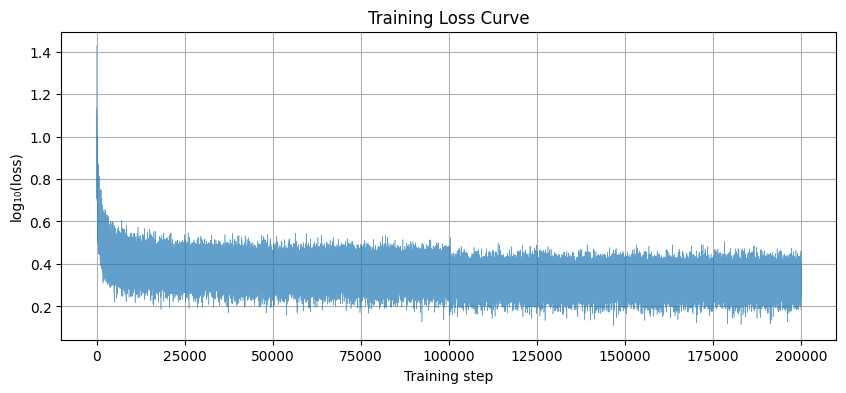

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(stepi, lossi, lw=0.4, alpha=0.7)
plt.xlabel('Training step')
plt.ylabel('log\u2081\u2080(loss)')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()

## 7. Evaluation

We compute the full-dataset loss on each split using `@torch.no_grad()` to skip
gradient bookkeeping (faster and uses less memory).

- **Train loss** — how well the model fits its training data
- **Dev loss** — proxy for generalization; used to tune hyperparameters
- **Test loss** — final unbiased estimate (look at this only once!)

A large **train–dev gap** indicates over-fitting.  
A **dev–train gap ≈ 0** with high loss indicates under-fitting (model too small or
training too short).

In [9]:
@torch.no_grad()   # disables gradient computation for the duration of this function
def evaluate_loss(X, Y, label):
    emb    = C[X]
    h      = torch.tanh(emb.view(-1, BLOCK_SIZE * EMBED_DIM) @ W1 + b1)
    logits = h @ W2 + b2
    loss   = F.cross_entropy(logits, Y)
    print(f"{label:6s} loss: {loss.item():.4f}")

evaluate_loss(Xtr,  Ytr,  'Train')
evaluate_loss(Xdev, Ydev, 'Dev')
evaluate_loss(Xte,  Yte,  'Test')

Train  loss: 2.1180
Dev    loss: 2.1611
Test   loss: 2.1579


## 8. Embedding Space Visualization

The embedding table `C` has shape `(27, EMBED_DIM)`. Even though `EMBED_DIM = 10`,
we can peek at the **first two learned dimensions** with a scatter plot.

Characters that frequently appear in similar left-contexts (e.g. vowels after
consonants) tend to cluster together — the model discovers this structure purely
from the name data.

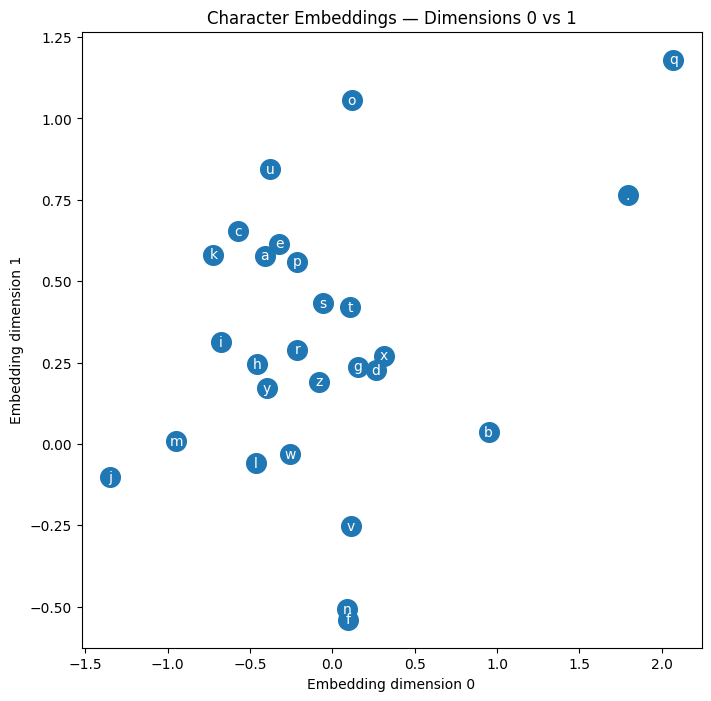

In [10]:
plt.figure(figsize=(8, 8))
# Scatter the first two embedding dimensions for every character
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i],
             ha='center', va='center', color='white')
plt.title('Character Embeddings — Dimensions 0 vs 1')
plt.xlabel('Embedding dimension 0')
plt.ylabel('Embedding dimension 1')
plt.grid(True, which='minor')
plt.show()

## 9. Sampling — Name Generation

After training, we use the model **autoregressively** to generate new names:

1. Start with a context of `BLOCK_SIZE` boundary tokens `[0, 0, 0]`
2. Run a forward pass → softmax probabilities over the vocabulary
3. Sample the next character index from that distribution
4. Append the sampled index to the context (drop the oldest)
5. Repeat until the model samples the boundary token `'.'` (index 0)

The generated names are novel — they are not in the training set, but they
have learned the statistical patterns of English names.

In [11]:
g_sample = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out     = []
    context = [0] * BLOCK_SIZE   # start with all boundary tokens

    while True:
        # Forward pass for a single context
        emb    = C[torch.tensor([context])]              # (1, BLOCK_SIZE, EMBED_DIM)
        h      = torch.tanh(emb.view(1, -1) @ W1 + b1)  # (1, HIDDEN_DIM)
        logits = h @ W2 + b2                             # (1, vocab_size)
        probs  = F.softmax(logits, dim=1)                # convert logits → probabilities

        # Sample one character index from the probability distribution
        ix      = torch.multinomial(probs, num_samples=1, generator=g_sample).item()
        context = context[1:] + [ix]   # slide context window right
        out.append(ix)

        if ix == 0:                    # boundary token → end of word
            break

    print(''.join(itos[i] for i in out[:-1]))  # decode and print (skip trailing '.')

carlah
amelle
khiim
shreet
khalaysie
mahube
deliah
jareei
ner
kentzeriavon
leigh
ham
jorn
quinn
shovera
jamii
wajerma
jarynix
kael
dura


In [12]:
# ── MLflow: log params, metrics, and model checkpoint ────────────────────────
import torch

@torch.no_grad()
def _loss(X, Y):
    emb    = C[X]
    h      = torch.tanh(emb.view(-1, BLOCK_SIZE * EMBED_DIM) @ W1 + b1)
    logits = h @ W2 + b2
    return F.cross_entropy(logits, Y).item()

train_loss = _loss(Xtr, Ytr)
dev_loss   = _loss(Xdev, Ydev)

mlflow.log_params({
    'block_size': BLOCK_SIZE,
    'embed_dim':  EMBED_DIM,
    'hidden_dim': HIDDEN_DIM,
    'max_steps':  MAX_STEPS,
    'batch_size': BATCH_SIZE,
    'vocab_size': vocab_size,
})
mlflow.log_metric('train_loss', train_loss)
mlflow.log_metric('dev_loss',   dev_loss)

ckpt_path = 'checkpoints/part2_mlp.pt'
torch.save({
    'C': C.data, 'W1': W1.data, 'b1': b1.data,
    'W2': W2.data, 'b2': b2.data,
    'stoi': stoi, 'itos': itos,
    'BLOCK_SIZE': BLOCK_SIZE, 'EMBED_DIM': EMBED_DIM, 'HIDDEN_DIM': HIDDEN_DIM,
}, ckpt_path)
mlflow.log_artifact(ckpt_path)

mlflow.end_run()
print(f'MLflow run complete  train={train_loss:.4f}  dev={dev_loss:.4f}  ckpt={ckpt_path}')

MLflow run complete  train=2.1180  dev=2.1611  ckpt=checkpoints/part2_mlp.pt
